Three-page dashboard generated successfully!
Saved in: /home/1b0e678d-c050-45a7-8129-3c2b6c4a323d/pandas/war_impact_figures_three_page


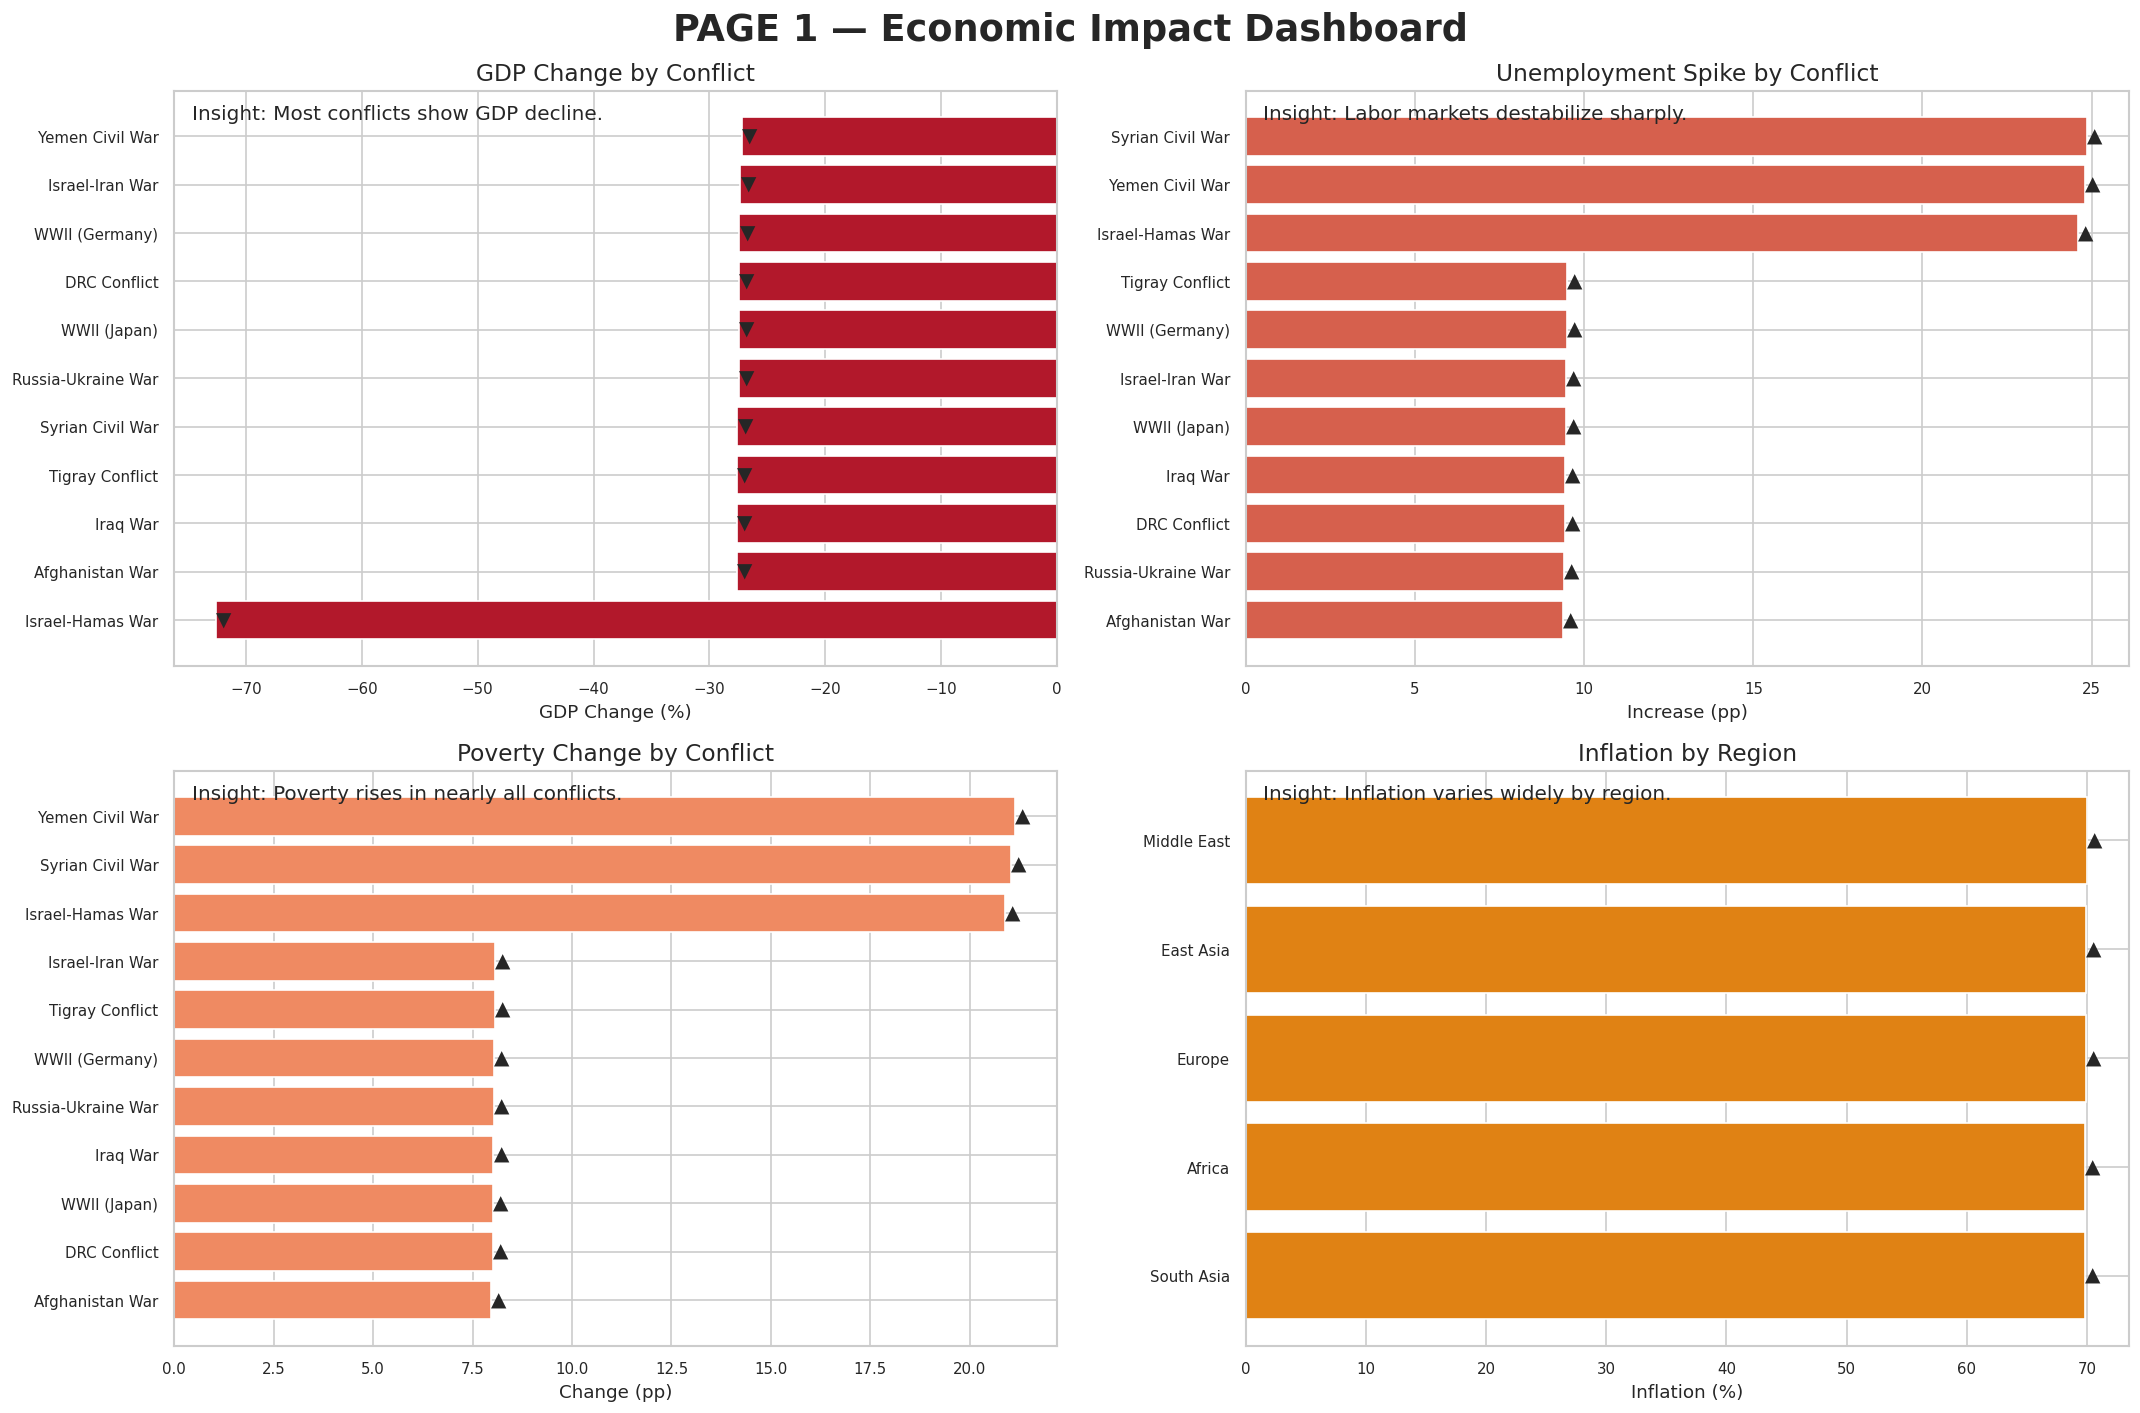

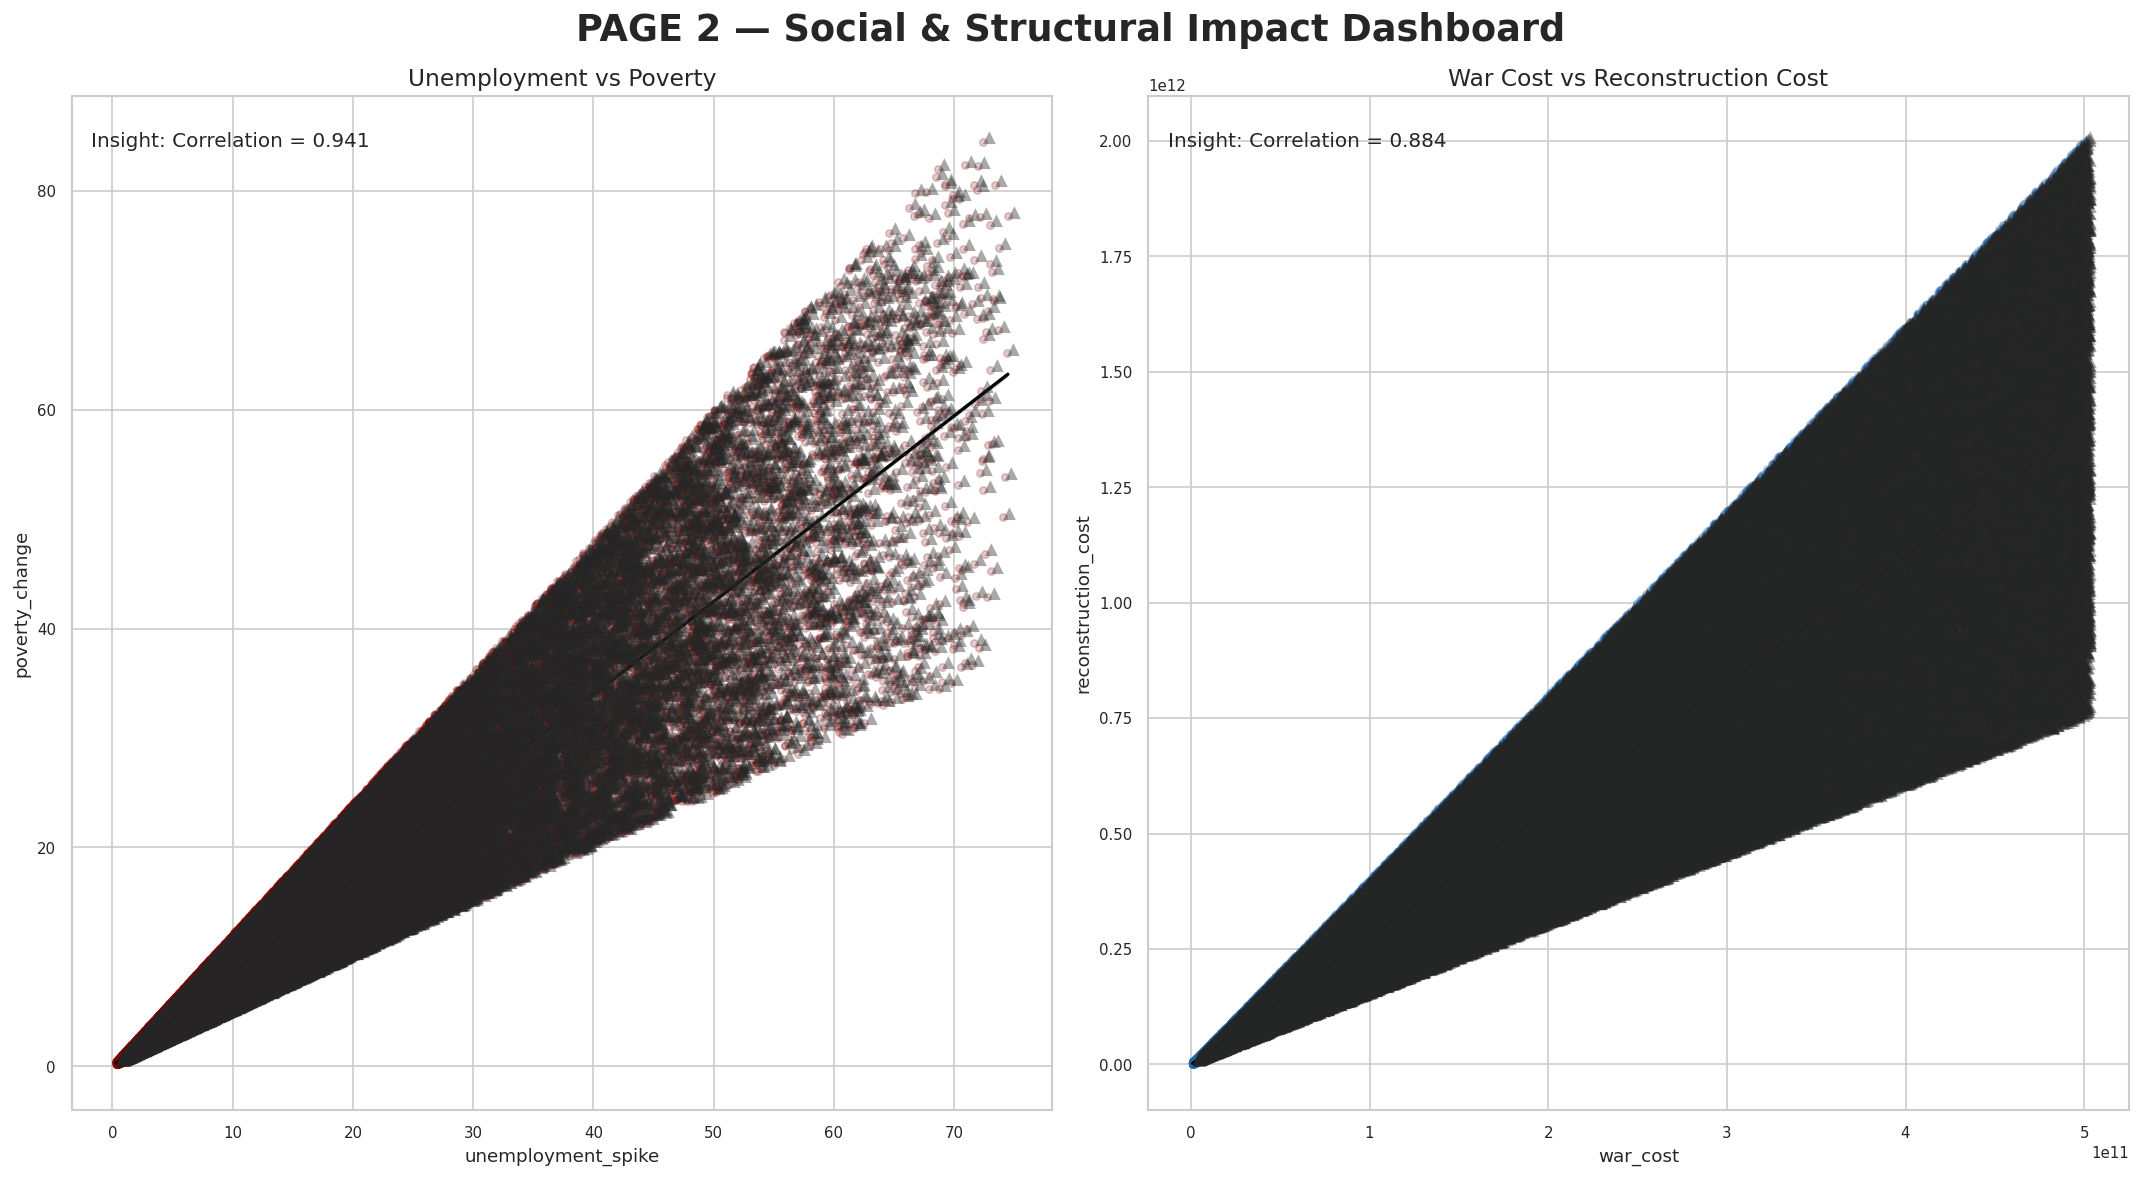

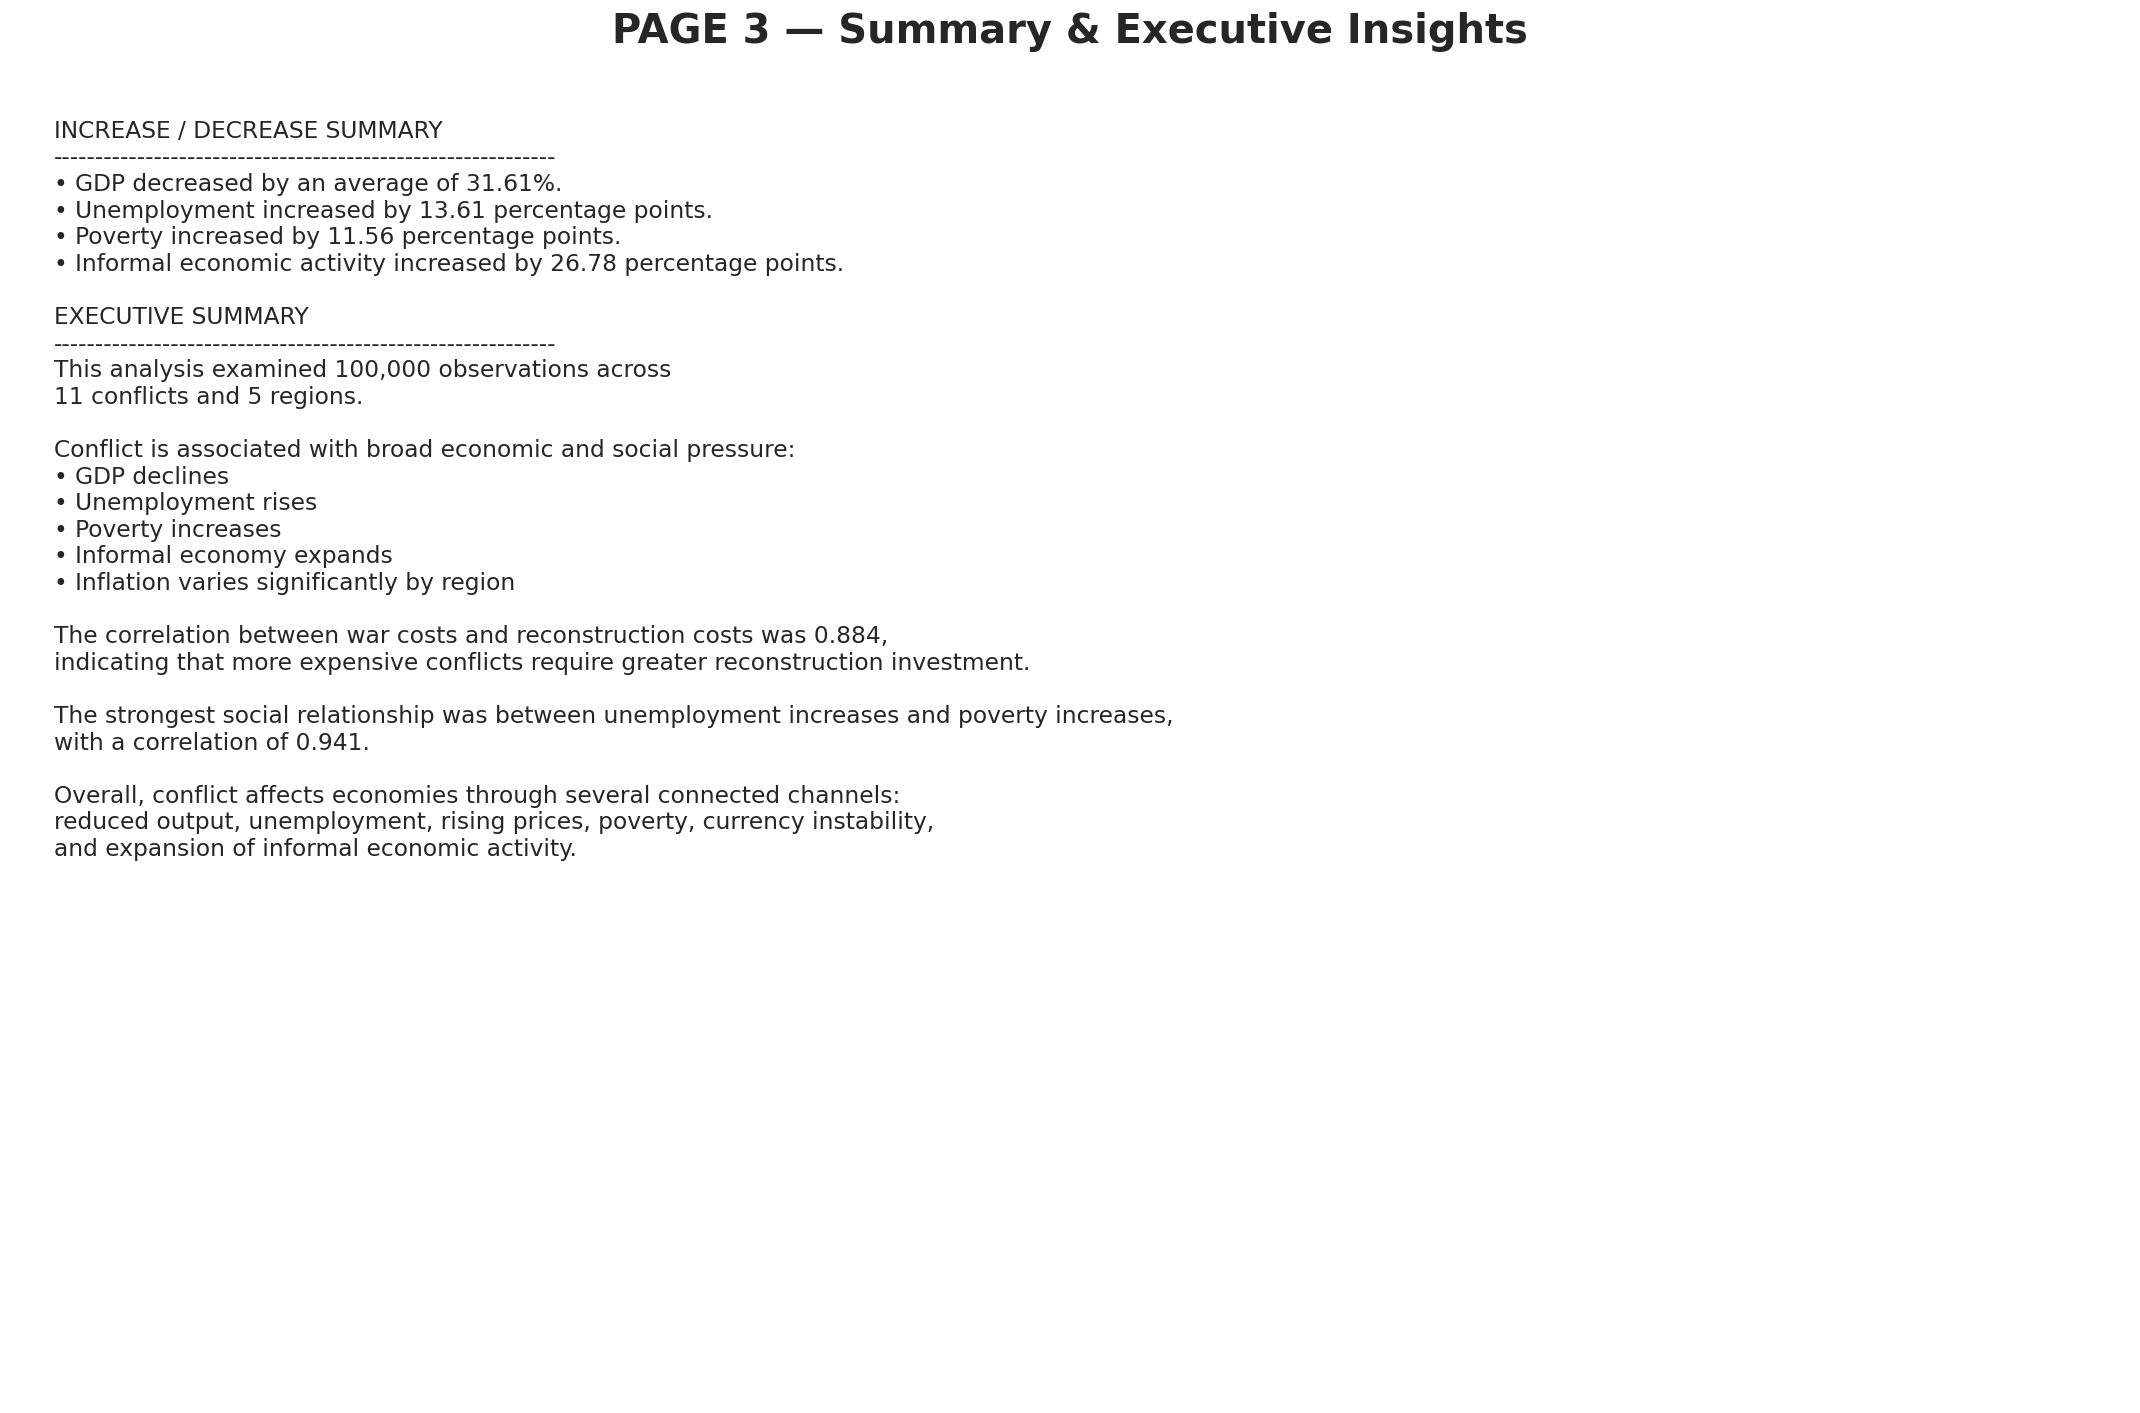

In [3]:
# ============================================================
# THREE-PAGE DASHBOARD: WAR'S ECONOMIC & SOCIAL IMPACT
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

DATA_PATH = Path("war_economic_impact_dataset.csv")
OUTPUT_DIR = Path("war_impact_figures_three_page")
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

# ------------------------------------------------------------
# 2. Load and prepare data
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH)

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace("%", "pct", regex=False)
      .str.replace(r"[^a-z0-9]+", "_", regex=True)
      .str.strip("_")
)

rename_columns = {
    "conflict_name": "conflict",
    "primary_country": "country",
    "pre_war_unemployment_pct": "pre_unemployment",
    "during_war_unemployment_pct": "during_unemployment",
    "unemployment_spike_percentage_points": "unemployment_spike",
    "pre_war_poverty_rate_pct": "pre_poverty",
    "during_war_poverty_rate_pct": "during_poverty",
    "youth_unemployment_change_pct": "youth_unemployment_change",
    "extreme_poverty_rate_pct": "extreme_poverty",
    "food_insecurity_rate_pct": "food_insecurity",
    "households_fallen_into_poverty_estimate": "households_into_poverty",
    "gdp_change_pct": "gdp_change",
    "inflation_rate_pct": "inflation",
    "currency_devaluation_pct": "currency_devaluation",
    "cost_of_war_usd": "war_cost",
    "estimated_reconstruction_cost_usd": "reconstruction_cost",
    "informal_economy_size_pre_war_pct": "informal_pre",
    "informal_economy_size_during_war_pct": "informal_during",
    "currency_black_market_rate_gap_pct": "black_market_rate_gap",
    "black_market_activity_level": "black_market_level",
    "primary_black_market_goods": "black_market_goods",
    "war_profiteering_documented": "war_profiteering",
    "most_affected_sector": "affected_sector",
}

df.rename(columns={old: new for old, new in rename_columns.items() if old in df.columns}, inplace=True)

text_columns = df.select_dtypes(include=["object", "string", "category"]).columns
for column in text_columns:
    df[column] = (
        df[column].astype("string")
        .str.strip()
        .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
        .fillna("Unknown")
    )

numeric_columns = [
    "start_year", "end_year", "pre_unemployment", "during_unemployment",
    "unemployment_spike", "youth_unemployment_change", "pre_poverty",
    "during_poverty", "extreme_poverty", "food_insecurity",
    "households_into_poverty", "gdp_change", "inflation",
    "currency_devaluation", "war_cost", "reconstruction_cost",
    "informal_pre", "informal_during", "black_market_rate_gap"
]

numeric_columns = [col for col in numeric_columns if col in df.columns]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(df[col].median())

# ------------------------------------------------------------
# 3. Feature engineering
# ------------------------------------------------------------

df["poverty_change"] = df["during_poverty"] - df["pre_poverty"]
df["informal_economy_change"] = df["informal_during"] - df["informal_pre"]
df["reconstruction_premium"] = (df["reconstruction_cost"] - df["war_cost"]) / df["war_cost"] * 100

# ------------------------------------------------------------
# 4. Aggregations
# ------------------------------------------------------------

conflict_summary = df.groupby("conflict", as_index=False).agg(
    observations=("conflict", "size"),
    gdp_change=("gdp_change", "mean"),
    unemployment_spike=("unemployment_spike", "mean"),
    poverty_change=("poverty_change", "mean"),
    inflation=("inflation", "mean"),
    informal_economy_change=("informal_economy_change", "mean"),
    war_cost=("war_cost", "mean"),
    reconstruction_cost=("reconstruction_cost", "mean"),
)

region_summary = df.groupby("region", as_index=False).agg(
    gdp_change=("gdp_change", "mean"),
    unemployment_spike=("unemployment_spike", "mean"),
    poverty_change=("poverty_change", "mean"),
    inflation=("inflation", "mean"),
    informal_economy_change=("informal_economy_change", "mean"),
)

# ------------------------------------------------------------
# 5. KPIs
# ------------------------------------------------------------

average_gdp_change = df["gdp_change"].mean()
average_unemployment_spike = df["unemployment_spike"].mean()
average_poverty_change = df["poverty_change"].mean()
average_inflation = df["inflation"].mean()
average_informal_change = df["informal_economy_change"].mean()

cost_correlation = df[["war_cost", "reconstruction_cost"]].corr().iloc[0, 1]
poverty_unemployment_correlation = df[["poverty_change", "unemployment_spike"]].corr().iloc[0, 1]

# ------------------------------------------------------------
# 6. PAGE 1 — Economic Impact Dashboard (with trend markers)
# ------------------------------------------------------------

fig1, axes = plt.subplots(2, 2, figsize=(18, 12))
fig1.suptitle("PAGE 1 — Economic Impact Dashboard", fontsize=22, fontweight="bold")

# GDP Change
plot_data = conflict_summary.sort_values("gdp_change")
colors = ["#b2182b" if v < 0 else "#2166ac" for v in plot_data["gdp_change"]]

axes[0, 0].barh(plot_data["conflict"], plot_data["gdp_change"], color=colors)
axes[0, 0].set_title("GDP Change by Conflict")
axes[0, 0].set_xlabel("GDP Change (%)")

for i, v in enumerate(plot_data["gdp_change"]):
    marker = "▲" if v > 0 else "▼"
    axes[0, 0].text(v, i, marker, fontsize=12, va="center")

axes[0, 0].text(0.02, 0.95, "Insight: Most conflicts show GDP decline.", transform=axes[0, 0].transAxes)

# Unemployment Spike
plot_data = conflict_summary.sort_values("unemployment_spike")
axes[0, 1].barh(plot_data["conflict"], plot_data["unemployment_spike"], color="#d6604d")
axes[0, 1].set_title("Unemployment Spike by Conflict")
axes[0, 1].set_xlabel("Increase (pp)")

for i, v in enumerate(plot_data["unemployment_spike"]):
    marker = "▲" if v > 0 else "▼"
    axes[0, 1].text(v, i, marker, fontsize=12, va="center")

axes[0, 1].text(0.02, 0.95, "Insight: Labor markets destabilize sharply.", transform=axes[0, 1].transAxes)

# Poverty Change
plot_data = conflict_summary.sort_values("poverty_change")
poverty_colors = ["#ef8a62" if v > 0 else "#2166ac" for v in plot_data["poverty_change"]]
axes[1, 0].barh(plot_data["conflict"], plot_data["poverty_change"], color=poverty_colors)
axes[1, 0].set_title("Poverty Change by Conflict")
axes[1, 0].set_xlabel("Change (pp)")

for i, v in enumerate(plot_data["poverty_change"]):
    marker = "▲" if v > 0 else "▼"
    axes[1, 0].text(v, i, marker, fontsize=12, va="center")

axes[1, 0].text(0.02, 0.95, "Insight: Poverty rises in nearly all conflicts.", transform=axes[1, 0].transAxes)

# Inflation by Region
plot_data = region_summary.sort_values("inflation")
axes[1, 1].barh(plot_data["region"], plot_data["inflation"], color="#e08214")
axes[1, 1].set_title("Inflation by Region")
axes[1, 1].set_xlabel("Inflation (%)")

for i, v in enumerate(plot_data["inflation"]):
    marker = "▲" if v > 0 else "▼"
    axes[1, 1].text(v, i, marker, fontsize=12, va="center")

axes[1, 1].text(0.02, 0.95, "Insight: Inflation varies widely by region.", transform=axes[1, 1].transAxes)

plt.tight_layout()
fig1.savefig(OUTPUT_DIR / "page1_economic_dashboard.png")

# ------------------------------------------------------------
# 7. PAGE 2 — Social & Structural Impact Dashboard (with trend markers)
# ------------------------------------------------------------

fig2, axes = plt.subplots(1, 2, figsize=(18, 10))
fig2.suptitle("PAGE 2 — Social & Structural Impact Dashboard", fontsize=22, fontweight="bold")

# Unemployment vs Poverty
sns.regplot(
    data=df,
    x="unemployment_spike",
    y="poverty_change",
    scatter_kws={"alpha": 0.2, "s": 20, "color": "#7f0000"},
    line_kws={"color": "black", "linewidth": 2},
    ax=axes[0]
)
axes[0].set_title("Unemployment vs Poverty")

for i in range(len(df)):
    marker = "▲" if df["poverty_change"].iloc[i] > 0 else "▼"
    axes[0].text(
        df["unemployment_spike"].iloc[i],
        df["poverty_change"].iloc[i],
        marker,
        fontsize=10,
        alpha=0.4
    )

axes[0].text(0.02, 0.95, f"Insight: Correlation = {poverty_unemployment_correlation:.3f}", transform=axes[0].transAxes)

# War Cost vs Reconstruction Cost
sns.regplot(
    data=df,
    x="war_cost",
    y="reconstruction_cost",
    scatter_kws={"alpha": 0.2, "s": 20, "color": "#2166ac"},
    line_kws={"color": "black", "linewidth": 2},
    ax=axes[1]
)
axes[1].set_title("War Cost vs Reconstruction Cost")

for i in range(len(df)):
    marker = "▲" if df["reconstruction_cost"].iloc[i] > df["war_cost"].iloc[i] else "▼"
    axes[1].text(
        df["war_cost"].iloc[i],
        df["reconstruction_cost"].iloc[i],
        marker,
        fontsize=10,
        alpha=0.4
    )

axes[1].text(0.02, 0.95, f"Insight: Correlation = {cost_correlation:.3f}", transform=axes[1].transAxes)

plt.tight_layout()
fig2.savefig(OUTPUT_DIR / "page2_social_dashboard.png")

# ------------------------------------------------------------
# 8. PAGE 3 — Summary Page
# ------------------------------------------------------------

fig3, ax = plt.subplots(figsize=(18, 12))
fig3.suptitle("PAGE 3 — Summary & Executive Insights", fontsize=24, fontweight="bold")

summary_text = f"""
INCREASE / DECREASE SUMMARY
------------------------------------------------------------
• GDP decreased by an average of {abs(average_gdp_change):.2f}%.
• Unemployment increased by {average_unemployment_spike:.2f} percentage points.
• Poverty increased by {average_poverty_change:.2f} percentage points.
• Informal economic activity increased by {average_informal_change:.2f} percentage points.

EXECUTIVE SUMMARY
------------------------------------------------------------
This analysis examined {len(df):,} observations across
{df['conflict'].nunique()} conflicts and {df['region'].nunique()} regions.

Conflict is associated with broad economic and social pressure:
• GDP declines
• Unemployment rises
• Poverty increases
• Informal economy expands
• Inflation varies significantly by region

The correlation between war costs and reconstruction costs was {cost_correlation:.3f},
indicating that more expensive conflicts require greater reconstruction investment.

The strongest social relationship was between unemployment increases and poverty increases,
with a correlation of {poverty_unemployment_correlation:.3f}.

Overall, conflict affects economies through several connected channels:
reduced output, unemployment, rising prices, poverty, currency instability,
and expansion of informal economic activity.
"""

ax.text(0.02, 0.98, summary_text, fontsize=14, va="top")
ax.axis("off")

plt.tight_layout()
fig3.savefig(OUTPUT_DIR / "page3_summary_dashboard.png")

print("Three-page dashboard generated successfully!")
print(f"Saved in: {OUTPUT_DIR.resolve()}")
